# Comprehensive LIBERO checkpoint analysis

Set `CHECKPOINT_FOLDER` in Section 1, then run the notebook from top to bottom. The notebook performs two complementary evaluations:

1. **Teacher-forced cached validation:** real five-step diffusion sampling on fixed validation conditions, decoded into raw 7D LIBERO commands.
2. **Closed-loop LIBERO rollout:** optional benchmark rollouts for action chunks 1 and 4, including videos and per-task success summaries.

The rollout section is disabled by default because it launches the full T5, Qwen, SigLIP, RDT, and LIBERO stack. Cached validation is useful for diagnosis, but rollout success remains the final policy metric.

In [16]:
# Section 0 — imports and repository discovery
import gc
import json
import os
import subprocess
import sys
from dataclasses import replace
from pathlib import Path

os.environ.setdefault('MUJOCO_GL', 'egl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp/thinkflow-cache')
os.environ.setdefault('MPLCONFIGDIR', '/tmp/thinkflow-matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, Video, display

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / 'src' / 'thinkflow_rdt').is_dir() and (candidate / 'scripts').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the ThinkFlow-RDT-1B repository root')

REPO_ROOT = find_repo_root(Path.cwd())
for path in (REPO_ROOT, REPO_ROOT / 'src', REPO_ROOT / 'scripts'):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))
print('Repository:', REPO_ROOT)
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'unavailable')

Repository: /home/ubuntu/ThinkFlow-RDT-1B
CUDA: True NVIDIA RTX 6000 Ada Generation


## 1. Configuration

Normally only `CHECKPOINT_FOLDER` needs changing. Add or remove suites and rollout chunks depending on how much evaluation you want to run.

In [17]:
# Section 1 — edit this cell
CHECKPOINT_FOLDER = REPO_ROOT / 'outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400'
BASE_ARTIFACT = REPO_ROOT / 'oxe_b0_merged_for_libero'
CONFIG_PATH = REPO_ROOT / 'configs/b0_rdt1b_lora.yaml'
CACHE_ROOT = REPO_ROOT / 'cache_features_libero_b0_raw_ortho6d'
LIBERO_ROOT = Path('/home/ubuntu/LIBERO')
SIGLIP_MODEL_ID = Path('/home/ubuntu/models/siglip-so400m-patch14-384')
SIGLIP_FALLBACK_MODEL_ID = 'google/siglip-so400m-patch14-384'

SUITES = ('libero_spatial', 'libero_object', 'libero_goal', 'libero_10')
OFFLINE_SAMPLES_PER_SUITE = 32
OFFLINE_BATCH_SIZE = 16
DIFFUSION_REPEATS = 1
INFERENCE_STEPS = 5
SEED = 42

# One randomly selected demonstration, evaluated before benchmark rollouts.
RUN_SINGLE_DEMO_ROLLOUT = False
DEMO_DATASET_ROOT = REPO_ROOT / 'libero-dataset'
SINGLE_DEMO_SUITE = 'libero_goal'  # Set to None to sample from all configured suites.
SINGLE_DEMO_RANDOM_SEED = 20260811
SINGLE_DEMO_ACTION_CHUNKS = (1, 4)
SINGLE_DEMO_MAX_STEPS = 300

# Closed-loop benchmark settings. Start with 2 episodes/task; increase after the smoke test.
RUN_ROLLOUTS = False
ROLLOUT_ACTION_CHUNKS = (1, 4)
ROLLOUT_EPISODES_PER_TASK = 2
ROLLOUT_TASK_IDS = None  # None means all ten tasks in each suite. Example: (0, 1)
ROLLOUT_ENV_BATCH_SIZE = 2
ROLLOUT_MAX_STEPS = 600
SAVE_VIDEOS = True
VIDEO_RESOLUTION = 512

checkpoint_tag = f'{CHECKPOINT_FOLDER.parent.name}__{CHECKPOINT_FOLDER.name}'
ANALYSIS_ROOT = REPO_ROOT / 'outputs/libero_checkpoint_analysis' / checkpoint_tag
ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)
print('Checkpoint:', CHECKPOINT_FOLDER)
print('Analysis output:', ANALYSIS_ROOT)

Checkpoint: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400
Analysis output: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_checkpoint_analysis/libero_object_task0_demo0_overfit_mask_aligned_balanced_500__checkpoint-2400


## 2. Checkpoint audit

This verifies the artifact layout and displays the saved training objective. `load_trainable_artifact` later restores `mask_noisy_gripper_input` from this metadata.

In [18]:
# Section 2 — artifact and dependency audit
required_paths = {
    'checkpoint': CHECKPOINT_FOLDER,
    'checkpoint interfaces': CHECKPOINT_FOLDER / 'interfaces.pt',
    'checkpoint metadata': CHECKPOINT_FOLDER / 'metadata.json',
    'base artifact': BASE_ARTIFACT / 'rdt_full.pt',
    'config': CONFIG_PATH,
    'LIBERO': LIBERO_ROOT,
}
missing = {name: str(path) for name, path in required_paths.items() if not path.exists()}
if missing:
    raise FileNotFoundError(f'Missing required paths: {missing}')
lora_candidates = (
    CHECKPOINT_FOLDER / 'rdt_lora' / 'adapter_model.safetensors',
    CHECKPOINT_FOLDER / 'adapter_model.safetensors',  # legacy layout
)
has_lora = any(path.exists() for path in lora_candidates)
has_full_rdt = (CHECKPOINT_FOLDER / 'rdt_full.pt').exists()
if not (has_lora or has_full_rdt):
    checked = [str(path) for path in (*lora_candidates, CHECKPOINT_FOLDER / 'rdt_full.pt')]
    raise FileNotFoundError(f'Checkpoint has neither a LoRA adapter nor rdt_full.pt; checked: {checked}')

metadata = json.loads((CHECKPOINT_FOLDER / 'metadata.json').read_text())
audit = {
    'checkpoint': str(CHECKPOINT_FOLDER),
    'global_step': metadata.get('global_step'),
    'effective_global_batch': metadata.get('effective_global_batch'),
    'pretrained_model': metadata.get('pretrained_model'),
    'mask_noisy_gripper_input': metadata.get('mask_noisy_gripper_input'),
    'training_objective': metadata.get('training_objective'),
    'artifact_format': 'lora' if has_lora else 'full',
    'artifact_files': {str(p.relative_to(CHECKPOINT_FOLDER)): p.stat().st_size for p in CHECKPOINT_FOLDER.rglob('*') if p.is_file()},
}
display(audit)
(ANALYSIS_ROOT / 'checkpoint_audit.json').write_text(json.dumps(audit, indent=2, default=str) + '\n')

{'checkpoint': '/home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400',
 'global_step': 2400,
 'effective_global_batch': 256,
 'pretrained_model': 'robotics-diffusion-transformer/rdt-1b',
 'mask_noisy_gripper_input': True,
 'training_objective': {'horizon_loss_weights': [5.0,
   5.0,
   5.0,
   5.0,
   3.0,
   3.0,
   3.0,
   3.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   2.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0,
   1.0],
  'mask_noisy_gripper_input': True,
  'gripper_bce_weight': 1.0,
  'gripper_bce_logit_scale': 5.0,
  'rotation_geodesic_weight': 1.0},
 'artifact_format': 'lo

1443

## 3. Build a fixed cached-validation audit set

The conditions are evenly spaced within each suite and remain fixed across repeated runs. SigLIP is computed once, then released before loading RDT to reduce GPU memory. Release phases are inferred with the same final close-to-open convention used by full validation.

In [19]:
# Section 3 — prepare fixed validation conditions
from scripts.overfit_libero_cached import (
    build_online_siglip_collator,
    encode_fixed_feature_batches,
    evaluate_real_sampling,
)
from thinkflow_rdt.adapters.libero import rdt_action_to_libero
from thinkflow_rdt.config import load_config
from thinkflow_rdt.data import ONLINE_SIGLIP_REQUIRED_KEYS, CachedFeatureDataset
from thinkflow_rdt.train import infer_gripper_release_mask, load_online_siglip

if not torch.cuda.is_available():
    raise RuntimeError('CUDA is required for RDT-1B sampling')
device = torch.device('cuda')
cfg = load_config(CONFIG_PATH)
saved_model_cfg = metadata.get('config', {}).get('model', {})
structural_keys = ('state_dim', 'action_dim', 'pred_horizon', 'hidden_size', 'qwen_fusion', 'state_encoder_layout', 'action_encoder_layout')
config_mismatches = {
    key: {'checkpoint': saved_model_cfg[key], 'yaml': getattr(cfg.model, key)}
    for key in structural_keys
    if key in saved_model_cfg and saved_model_cfg[key] != getattr(cfg.model, key)
}
if config_mismatches:
    raise ValueError(f'Checkpoint/config structural mismatch: {config_mismatches}')
cfg = replace(cfg, noise_scheduler=replace(cfg.noise_scheduler, num_inference_timesteps=INFERENCE_STEPS))
if cfg.model.action_encoder_layout != 'libero_ortho6d':
    raise ValueError(f'Expected libero_ortho6d, got {cfg.model.action_encoder_layout}')

siglip_id = str(SIGLIP_MODEL_ID) if SIGLIP_MODEL_ID.exists() else SIGLIP_FALLBACK_MODEL_ID
processor, siglip = load_online_siglip(
    model_id=siglip_id, fallback_model_id=SIGLIP_FALLBACK_MODEL_ID, cfg=cfg, device=device
)
collator = build_online_siglip_collator(cfg)
suite_batches = {}
sample_audit = {}

for suite in SUITES:
    manifest = CACHE_ROOT / suite / 'validation/manifest.jsonl'
    if not manifest.exists():
        raise FileNotFoundError(manifest)
    dataset = CachedFeatureDataset(manifest, required_keys=ONLINE_SIGLIP_REQUIRED_KEYS)
    count = min(OFFLINE_SAMPLES_PER_SUITE, len(dataset))
    indices = np.unique(np.linspace(0, len(dataset) - 1, count, dtype=int)).tolist()
    samples = [dataset[index] for index in indices]
    batches = encode_fixed_feature_batches(
        samples, cfg=cfg, batch_size=OFFLINE_BATCH_SIZE, device=device,
        collator=collator, processor=processor, encoder=siglip,
    )
    release_commands = 0
    release_samples = 0
    for batch in batches:
        raw_target = torch.from_numpy(rdt_action_to_libero(batch['actions'].float().numpy()))
        release = infer_gripper_release_mask(raw_target[..., 6], batch['action_time_mask'].bool())
        batch['gripper_release_mask'] = release
        release_commands += int(release.sum())
        release_samples += int(release.any(dim=1).sum())
    suite_batches[suite] = batches
    sample_audit[suite] = {
        'dataset_samples': len(dataset), 'selected_samples': len(indices),
        'release_commands': release_commands, 'release_samples': release_samples,
    }
    print(suite, sample_audit[suite])

del siglip, processor
gc.collect()
torch.cuda.empty_cache()
(ANALYSIS_ROOT / 'offline_sample_audit.json').write_text(json.dumps(sample_audit, indent=2) + '\n')

Loading weights: 100%|██████████| 448/448 [00:00<00:00, 1208.73it/s]
[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-so400m-patch14-384
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...26}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm2.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...26}.self_attn.ou

libero_spatial {'dataset_samples': 5420, 'selected_samples': 32, 'release_commands': 271, 'release_samples': 22}
libero_object {'dataset_samples': 7043, 'selected_samples': 32, 'release_commands': 260, 'release_samples': 20}
libero_goal {'dataset_samples': 7690, 'selected_samples': 32, 'release_commands': 259, 'release_samples': 20}
libero_10 {'dataset_samples': 14345, 'selected_samples': 32, 'release_commands': 346, 'release_samples': 15}


551

## 4. Load the checkpoint and run real diffusion sampling

In [20]:
# Section 4 — model load
from thinkflow_rdt.checkpoint import load_trainable_artifact
from thinkflow_rdt.model import SFTConditionedRDT

model = SFTConditionedRDT(cfg, load_pretrained=True, base_artifact=str(BASE_ARTIFACT))
load_trainable_artifact(model, CHECKPOINT_FOLDER, trainable=False)
model.to(device).eval()
print('Loaded checkpoint step:', metadata.get('global_step'))
print('mask_noisy_gripper_input:', model.mask_noisy_gripper_input)
print('model dtype:', model.model_dtype)
print('allocated CUDA GiB:', torch.cuda.memory_allocated() / 2**30)

Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Loaded checkpoint step: 2400
mask_noisy_gripper_input: True
model dtype: torch.bfloat16
allocated CUDA GiB: 2.449234962463379


In [21]:
# Section 4.1 — combined and per-suite sampled-command metrics
def add_phase_sample_counts(metrics, tensors):
    if 'gripper_release_mask' not in tensors:
        return metrics
    predicted = torch.from_numpy(rdt_action_to_libero(tensors['prediction_10d'].numpy()))
    target = torch.from_numpy(rdt_action_to_libero(tensors['target_10d'].numpy()))
    valid = tensors['time_mask'].bool()
    release = tensors['gripper_release_mask'].bool() & valid
    close_hold = valid & (target[..., 6] >= 0)
    approach = valid & (target[..., 6] < 0) & ~release
    for name, mask in (('approach_open', approach), ('close_hold', close_hold), ('release_open', release)):
        metrics['gripper_phase'][name]['samples'] = int(mask.any(dim=1).sum())
    return metrics

offline_metrics = {}
offline_tensors = {}
for suite, batches in suite_batches.items():
    metrics, tensors = evaluate_real_sampling(
        model, batches, device=device, repeats=DIFFUSION_REPEATS, seed=SEED + 1_000_000
    )
    offline_metrics[suite] = add_phase_sample_counts(metrics, tensors)
    offline_tensors[suite] = tensors

all_batches = [batch for suite in SUITES for batch in suite_batches[suite]]
combined_metrics, combined_tensors = evaluate_real_sampling(
    model, all_batches, device=device, repeats=DIFFUSION_REPEATS, seed=SEED + 2_000_000
)
offline_metrics['combined'] = add_phase_sample_counts(combined_metrics, combined_tensors)
offline_tensors['combined'] = combined_tensors
model.eval()

metrics_path = ANALYSIS_ROOT / 'offline_real_sampling_metrics.json'
metrics_path.write_text(json.dumps(offline_metrics, indent=2, default=str) + '\n')
torch.save(offline_tensors, ANALYSIS_ROOT / 'offline_real_sampling_tensors.pt')
print('Saved:', metrics_path)
display(offline_metrics['combined'])

Saved: /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_checkpoint_analysis/libero_object_task0_demo0_overfit_mask_aligned_balanced_500__checkpoint-2400/offline_real_sampling_metrics.json


{'horizon_rmse': {'1': {'command_rmse_7d': 0.2414325326681137,
   'motion_rmse_6d': 0.18193502724170685,
   'gripper_rmse': 0.45763036608695984,
   'valid_commands': 128},
  '4': {'command_rmse_7d': 0.24357233941555023,
   'motion_rmse_6d': 0.18539908528327942,
   'gripper_rmse': 0.45722582936286926,
   'valid_commands': 490},
  '8': {'command_rmse_7d': 0.24835476279258728,
   'motion_rmse_6d': 0.18912911415100098,
   'gripper_rmse': 0.46598467230796814,
   'valid_commands': 961},
  '64': {'command_rmse_7d': 0.3053223788738251,
   'motion_rmse_6d': 0.22168518602848053,
   'gripper_rmse': 0.5980688333511353,
   'valid_commands': 6248}},
 'per_dimension_correlation': {'dx': 0.5824385637369036,
  'dy': 0.7310264971939147,
  'dz': 0.6510332856510807,
  'dRx': 0.533321058495201,
  'dRy': 0.4165872908553441,
  'dRz': 0.7226946576841105,
  'gripper': 0.799243392095788},
 'per_dimension_sign_agreement': {'dx': 0.5832266325224071,
  'dy': 0.5886683738796414,
  'dz': 0.7059859154929577,
  'dRx':

## 5. Cached-validation tables and plots

In [22]:
# Section 5 — compact metric tables
horizon_rows = []
for suite, report in offline_metrics.items():
    for horizon, values in report['horizon_rmse'].items():
        if values is not None:
            horizon_rows.append({'suite': suite, 'horizon': int(horizon), **values})
horizon_df = pd.DataFrame(horizon_rows).sort_values(['suite', 'horizon'])

dimension_rows = []
for suite, report in offline_metrics.items():
    for dimension in report['per_dimension_correlation']:
        dimension_rows.append({
            'suite': suite, 'dimension': dimension,
            'correlation': report['per_dimension_correlation'][dimension],
            'sign_agreement': report['per_dimension_sign_agreement'][dimension],
            'saturation_fraction': report['per_dimension_saturation_fraction'][dimension],
        })
dimension_df = pd.DataFrame(dimension_rows)

phase_rows = []
for suite, report in offline_metrics.items():
    for phase, values in report.get('gripper_phase', {}).items():
        phase_rows.append({'suite': suite, 'phase': phase, **values})
phase_df = pd.DataFrame(phase_rows)

display(horizon_df)
display(dimension_df[dimension_df.suite == 'combined'])
display(pd.DataFrame([offline_metrics['combined']['gripper']]))
display(phase_df[phase_df.suite == 'combined'])

,suite,horizon,command_rmse_7d,motion_rmse_6d,gripper_rmse,valid_commands
16,combined,1,0.241433,0.181935,0.457630,128
17,combined,4,0.243572,0.185399,0.457226,490
18,combined,8,0.248355,0.189129,0.465985,961
19,combined,64,0.305322,0.221685,0.598069,6248
12,libero_10,1,0.258082,0.174805,0.531887,32
13,libero_10,4,0.227894,0.169914,0.436263,123
14,libero_10,8,0.217535,0.159686,0.422202,243
15,libero_10,64,0.233749,0.183816,0.423960,1759
8,libero_goal,1,0.229769,0.216390,0.297672,32
9,libero_goal,4,0.238146,0.216338,0.340857,121


,suite,dimension,correlation,sign_agreement,saturation_fraction
28,combined,dx,0.582439,0.583227,0.003201
29,combined,dy,0.731026,0.588668,0.001761
30,combined,dz,0.651033,0.705986,0.004641
31,combined,dRx,0.533321,0.361876,0.000000
32,combined,dRy,0.416587,0.496799,0.000000
33,combined,dRz,0.722695,0.529289,0.000000
34,combined,gripper,0.799243,0.878041,0.659251


,positive_class,accuracy,precision,recall,f1,tp,fp,fn,tn
0,raw_command_ge_0,0.878041,0.887122,0.908795,0.897828,3348,426,336,2138


,suite,phase,accuracy,commands,samples,opportunities,detected,missed,mean_signed_error_steps,mae_steps
16,combined,approach_open,0.918768,1428.0,44.0,NaN,NaN,NaN,NaN,NaN
17,combined,close_hold,0.908795,3684.0,100.0,NaN,NaN,NaN,NaN,NaN
18,combined,release_open,0.727113,1136.0,77.0,NaN,NaN,NaN,NaN,NaN
19,combined,release_transition_timing,NaN,NaN,NaN,58.0,37.0,21.0,0.810811,5.621622


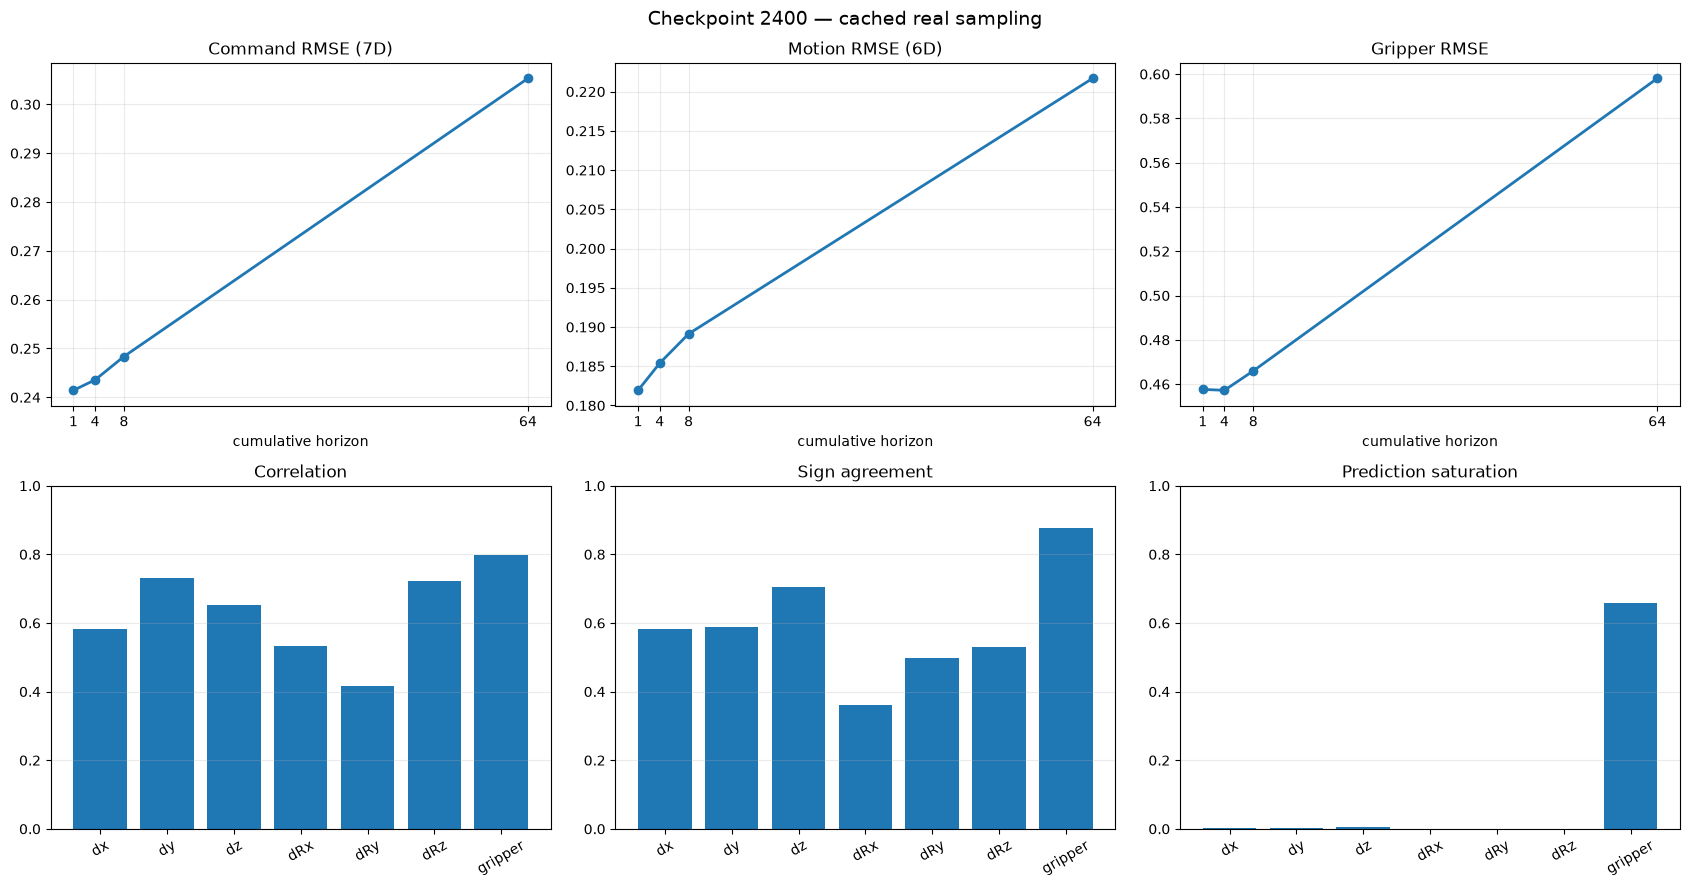

In [23]:
# Section 5.1 — horizon degradation and per-dimension quality
combined_horizon = horizon_df[horizon_df.suite == 'combined']
combined_dimension = dimension_df[dimension_df.suite == 'combined']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, key, title in zip(
    axes[0],
    ('command_rmse_7d', 'motion_rmse_6d', 'gripper_rmse'),
    ('Command RMSE (7D)', 'Motion RMSE (6D)', 'Gripper RMSE'),
):
    ax.plot(combined_horizon.horizon, combined_horizon[key], marker='o', linewidth=2)
    ax.set_xticks([1, 4, 8, 64]); ax.set_title(title); ax.set_xlabel('cumulative horizon')
    ax.grid(alpha=0.25)
for ax, key, title in zip(
    axes[1],
    ('correlation', 'sign_agreement', 'saturation_fraction'),
    ('Correlation', 'Sign agreement', 'Prediction saturation'),
):
    ax.bar(combined_dimension.dimension, combined_dimension[key])
    ax.set_ylim(0, 1); ax.set_title(title); ax.tick_params(axis='x', rotation=30); ax.grid(axis='y', alpha=0.25)
fig.suptitle(f'Checkpoint {metadata.get("global_step")} — cached real sampling', fontsize=14)
plt.tight_layout()
plt.savefig(ANALYSIS_ROOT / 'offline_command_quality.png', dpi=160, bbox_inches='tight')
plt.show()

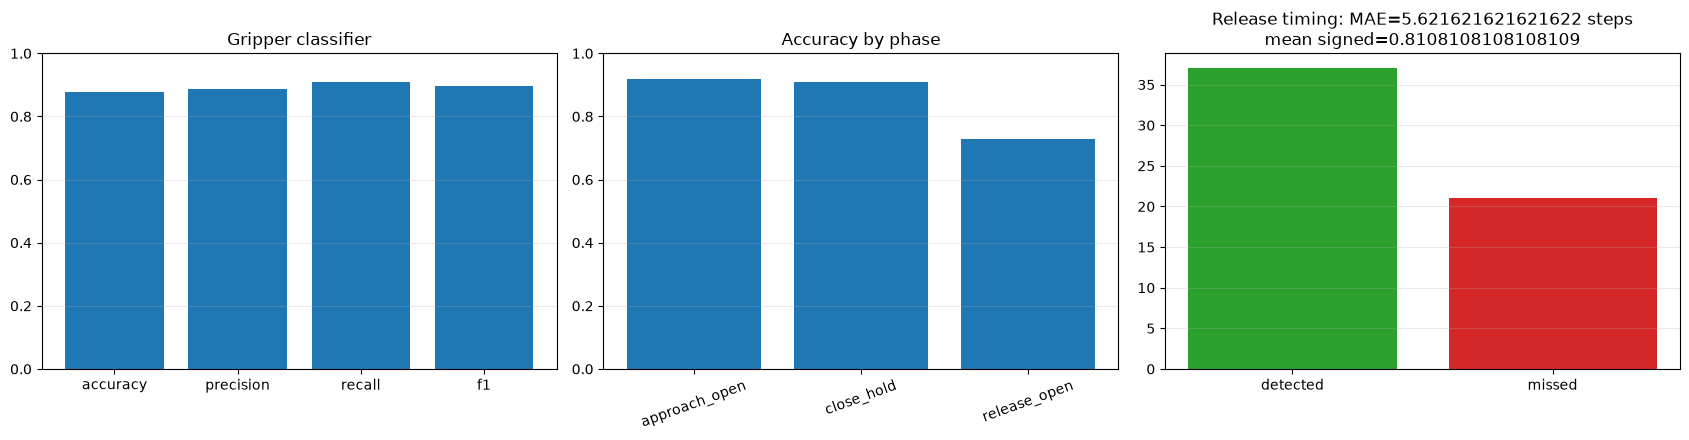

,phase,accuracy,commands,samples
0,approach_open,0.918768,1428,44
1,close_hold,0.908795,3684,100
2,release_open,0.727113,1136,77


{'opportunities': 58,
 'detected': 37,
 'missed': 21,
 'mean_signed_error_steps': 0.8108108108108109,
 'mae_steps': 5.621621621621622}

In [24]:
# Section 5.2 — gripper classifier, phases, and transition timing
gripper = offline_metrics['combined']['gripper']
phase = offline_metrics['combined'].get('gripper_phase', {})
timing = phase.get('release_transition_timing', {})
phase_names = ['approach_open', 'close_hold', 'release_open']
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].bar(['accuracy', 'precision', 'recall', 'f1'], [gripper[k] for k in ('accuracy', 'precision', 'recall', 'f1')])
axes[0].set_ylim(0, 1); axes[0].set_title('Gripper classifier'); axes[0].grid(axis='y', alpha=0.25)
axes[1].bar(phase_names, [phase[name]['accuracy'] for name in phase_names])
axes[1].set_ylim(0, 1); axes[1].set_title('Accuracy by phase'); axes[1].tick_params(axis='x', rotation=20); axes[1].grid(axis='y', alpha=0.25)
axes[2].bar(['detected', 'missed'], [timing.get('detected', 0), timing.get('missed', 0)], color=['tab:green', 'tab:red'])
axes[2].set_title(f"Release timing: MAE={timing.get('mae_steps')} steps\nmean signed={timing.get('mean_signed_error_steps')}")
axes[2].grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.savefig(ANALYSIS_ROOT / 'offline_gripper_quality.png', dpi=160, bbox_inches='tight')
plt.show()

display(pd.DataFrame([
    {'phase': name, 'accuracy': phase[name]['accuracy'], 'commands': phase[name]['commands'], 'samples': phase[name].get('samples')}
    for name in phase_names
]))
display(timing)

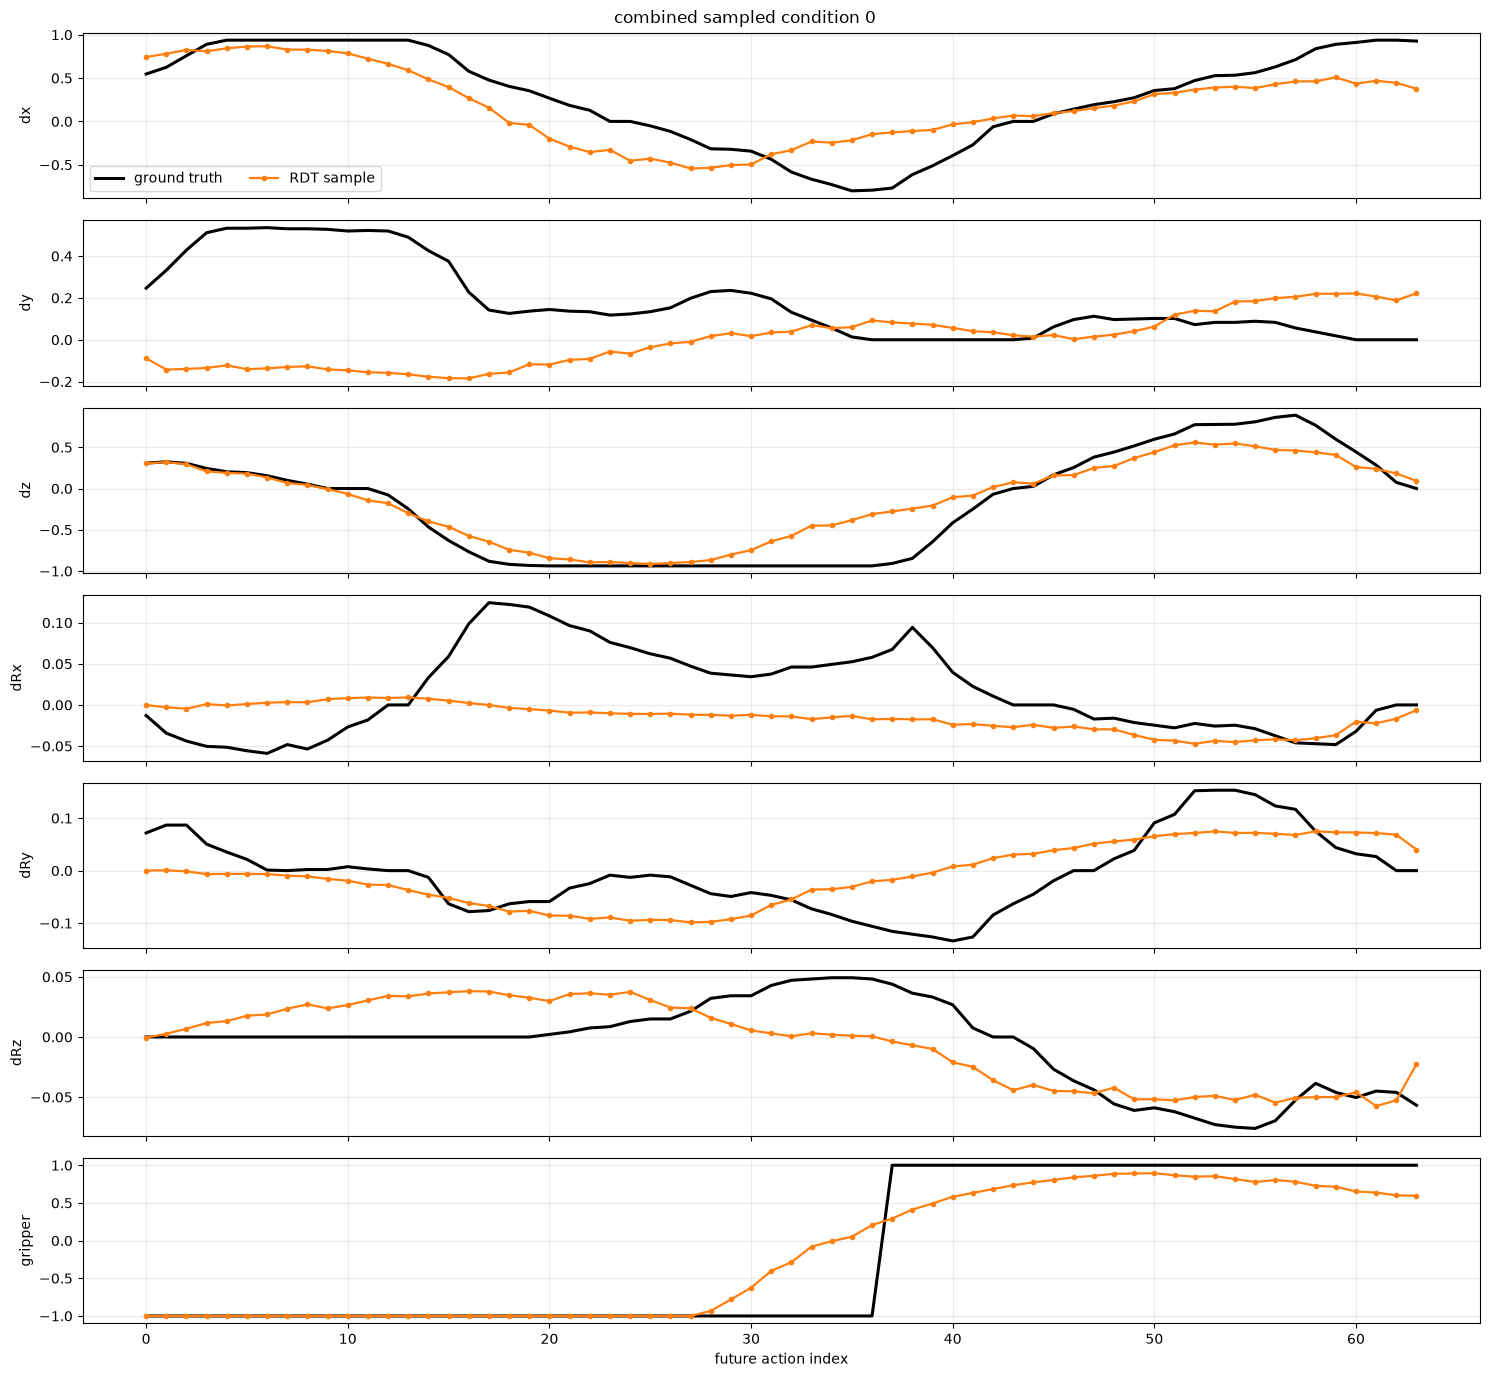

In [25]:
# Section 5.3 — inspect complete predicted and target command trajectories
TRACE_SUITE = 'combined'
TRACE_SAMPLE_INDEX = 0
trace = offline_tensors[TRACE_SUITE]
predicted_7d = rdt_action_to_libero(trace['prediction_10d'][TRACE_SAMPLE_INDEX].numpy())
target_7d = rdt_action_to_libero(trace['target_10d'][TRACE_SAMPLE_INDEX].numpy())
valid_count = int(trace['time_mask'][TRACE_SAMPLE_INDEX].sum())
names = ('dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper')
fig, axes = plt.subplots(7, 1, figsize=(15, 14), sharex=True)
for dimension, ax in enumerate(axes):
    steps = np.arange(valid_count)
    ax.plot(steps, target_7d[:valid_count, dimension], color='black', linewidth=2.2, label='ground truth', zorder=2)
    ax.plot(steps, predicted_7d[:valid_count, dimension], color='tab:orange', linewidth=1.6, marker='.', label='RDT sample', zorder=3)
    ax.set_ylabel(names[dimension]); ax.grid(alpha=0.25)
    if dimension == 0: ax.legend(ncol=2)
axes[-1].set_xlabel('future action index')
fig.suptitle(f'{TRACE_SUITE} sampled condition {TRACE_SAMPLE_INDEX}')
plt.tight_layout()
plt.savefig(ANALYSIS_ROOT / f'offline_trace_{TRACE_SUITE}_{TRACE_SAMPLE_INDEX}.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. One random demonstration: chunk 1 versus chunk 4

This diagnostic selects one reproducible random task and demonstration from the four requested suites. Both rollouts start from the demonstration's exact MuJoCo state and run for at most 300 environment steps. At nominal timestep `t`, it compares the executed RDT command with demonstrated command `t`, then compares the observed state after execution with demonstrated state `t+1`.

After the policy diverges physically from the demonstration, command differences include both prediction error and the fact that RDT is now responding to a different scene. That divergence is precisely what this closed-loop test is intended to reveal. Set `RUN_SINGLE_DEMO_ROLLOUT=True` in Section 1 to execute it.

In [26]:
RUN_SINGLE_DEMO_ROLLOUT = True
DEMO_DATASET_ROOT=Path("libero-dataset")

In [27]:
# Section 6 — reproducibly select one random task and demo
import h5py

if str(LIBERO_ROOT) not in sys.path:
    sys.path.insert(0, str(LIBERO_ROOT))
from libero.libero.benchmark import get_benchmark
from thinkflow_rdt.adapters.libero import iter_libero_episodes

single_demo_suite = globals().get('SINGLE_DEMO_SUITE', 'libero_goal')
if single_demo_suite is not None and single_demo_suite not in SUITES:
    raise ValueError(f'SINGLE_DEMO_SUITE must be one of {SUITES} or None, got {single_demo_suite!r}')
selection_suites = SUITES if single_demo_suite is None else (single_demo_suite,)
single_demo_random_seed = int(globals().get('SINGLE_DEMO_RANDOM_SEED', 20260811))
single_demo_action_chunks = tuple(globals().get('SINGLE_DEMO_ACTION_CHUNKS', (1, 4)))
single_demo_max_steps = int(globals().get('SINGLE_DEMO_MAX_STEPS', 300))
run_single_demo_rollout = bool(globals().get('RUN_SINGLE_DEMO_ROLLOUT', False))
resolved_demo_dataset_root = Path(globals().get('DEMO_DATASET_ROOT', REPO_ROOT / 'libero-dataset')).expanduser()
if not resolved_demo_dataset_root.is_absolute():
    resolved_demo_dataset_root = REPO_ROOT / resolved_demo_dataset_root
resolved_demo_dataset_root = resolved_demo_dataset_root.resolve()
demo_candidates = []
for suite in selection_suites:
    benchmark = get_benchmark(suite)(0)
    for task_id in range(10):
        task = benchmark.get_task(task_id)
        demo_path = resolved_demo_dataset_root / suite / f'{task.name}_demo.hdf5'
        if demo_path.exists():
            demo_candidates.append({
                'suite': suite, 'task_id': task_id, 'task_name': task.name,
                'instruction': task.language, 'demo_path': demo_path,
            })
if not demo_candidates:
    raise FileNotFoundError(f'No LIBERO HDF5 demonstrations below {resolved_demo_dataset_root}')

demo_rng = np.random.default_rng(single_demo_random_seed)
selected_demo = dict(demo_candidates[int(demo_rng.integers(len(demo_candidates)))])
with h5py.File(selected_demo['demo_path'], 'r') as handle:
    demo_root = handle['data'] if 'data' in handle else handle
    available_demo_names = sorted(
        [name for name in demo_root if hasattr(demo_root[name], 'keys') and 'actions' in demo_root[name]],
        key=lambda name: int(name.rsplit('_', 1)[-1]),
    )
selected_demo['demo_name'] = available_demo_names[int(demo_rng.integers(len(available_demo_names)))]
selected_demo = {key: (str(value) if isinstance(value, Path) else value) for key, value in selected_demo.items()}
display({
    **selected_demo, 'suite_filter': single_demo_suite, 'random_seed': single_demo_random_seed,
    'action_chunks': single_demo_action_chunks, 'max_steps': single_demo_max_steps,
    'run_enabled': run_single_demo_rollout,
})
(ANALYSIS_ROOT / 'selected_demo.json').write_text(json.dumps(selected_demo, indent=2) + '\n')

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


{'suite': 'libero_goal',
 'task_id': 5,
 'task_name': 'push_the_plate_to_the_front_of_the_stove',
 'instruction': 'push the plate to the front of the stove',
 'demo_path': '/home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_goal/push_the_plate_to_the_front_of_the_stove_demo.hdf5',
 'demo_name': 'demo_13',
 'suite_filter': 'libero_goal',
 'random_seed': 20260811,
 'action_chunks': (1, 4),
 'max_steps': 300,
 'run_enabled': True}

317

In [28]:
# Section 6.1 — construct and optionally execute chunk-1/chunk-4 traces
single_demo_dir = ANALYSIS_ROOT / 'single_demo'
single_demo_dir.mkdir(parents=True, exist_ok=True)
single_demo_jobs = {}
for chunk in single_demo_action_chunks:
    prefix = single_demo_dir / f"{selected_demo['suite']}_task{selected_demo['task_id']}_{selected_demo['demo_name']}_chunk{chunk}"
    paths = {
        'video': prefix.with_suffix('.mp4'),
        'trace': prefix.with_name(prefix.name + '_actions.jsonl'),
        'observations': prefix.with_name(prefix.name + '_observations.npz'),
        'summary': prefix.with_suffix('.json'),
    }
    command = [
        sys.executable, str(REPO_ROOT / 'scripts/rollout_libero_rdt.py'),
        '--config', str(CONFIG_PATH), '--benchmark', selected_demo['suite'],
        '--task-id', str(selected_demo['task_id']), '--checkpoint', str(CHECKPOINT_FOLDER),
        '--base-artifact', str(BASE_ARTIFACT), '--cache-root', str(CACHE_ROOT / selected_demo['suite']),
        '--libero-root', str(LIBERO_ROOT), '--demo-hdf5', selected_demo['demo_path'],
        '--demo-name', selected_demo['demo_name'], '--action-chunk', str(chunk),
        '--max-steps', str(single_demo_max_steps), '--seed', str(SEED),
        '--qwen-refresh-every', '1', '--clean-x0-gripper',
        '--siglip-model-id', siglip_id, '--video-resolution', str(VIDEO_RESOLUTION),
        '--output', str(paths['video']), '--action-debug-jsonl', str(paths['trace']),
        '--observation-debug-npz', str(paths['observations']),
    ]
    single_demo_jobs[chunk] = {'command': command, **paths}
    print(f'\nCHUNK {chunk}:')
    print(' '.join(command))

if not run_single_demo_rollout:
    print('\nSingle-demo rollouts are disabled. Set RUN_SINGLE_DEMO_ROLLOUT=True in Section 1 when ready.')
else:
    if 'model' in globals():
        del model
    gc.collect(); torch.cuda.empty_cache()
    for chunk, job in single_demo_jobs.items():
        complete = job['trace'].exists() and job['observations'].exists() and job['summary'].exists()
        if complete:
            print(f'Reusing existing chunk-{chunk} trace. Delete its files to rerun.')
            continue
        print(f'\n=== Running exact-demo chunk {chunk} ===', flush=True)
        subprocess.run(job['command'], cwd=REPO_ROOT, check=True)


CHUNK 1:
/home/ubuntu/ThinkFlow-RDT-1B/.venv/bin/python /home/ubuntu/ThinkFlow-RDT-1B/scripts/rollout_libero_rdt.py --config /home/ubuntu/ThinkFlow-RDT-1B/configs/b0_rdt1b_lora.yaml --benchmark libero_goal --task-id 5 --checkpoint /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400 --base-artifact /home/ubuntu/ThinkFlow-RDT-1B/oxe_b0_merged_for_libero --cache-root /home/ubuntu/ThinkFlow-RDT-1B/cache_features_libero_b0_raw_ortho6d/libero_goal --libero-root /home/ubuntu/LIBERO --demo-hdf5 /home/ubuntu/ThinkFlow-RDT-1B/libero-dataset/libero_goal/push_the_plate_to_the_front_of_the_stove_demo.hdf5 --demo-name demo_13 --action-chunk 1 --max-steps 300 --seed 42 --qwen-refresh-every 1 --clean-x0-gripper --siglip-model-id google/siglip-so400m-patch14-384 --video-resolution 512 --output /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_checkpoint_analysis/libero_object_task0_demo0_overfit_mask_aligned_balanced_500__checkpoint-2400/single_

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:04<00:00, 49.27it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=1 success=False elapsed=4.0s
plan=2 simulator_step=2 success=False elapsed=5.9s
plan=3 simulator_step=3 success=False elapsed=7.2s
plan=4 simulator_step=4 success=False elapsed=8.2s
plan=5 simulator_step=5 success=False elapsed=9.2s
plan=6 simulator_step=6 success=False elapsed=10.3s
plan=7 simulator_step=7 success=False elapsed=11.3s
plan=8 simulator_step=8 success=False elapsed=12.3s
plan=9 simulator_step=9 success=False elapsed=13.3s
plan=10 simulator_step=10 success=False elapsed=14.2s
plan=11 simulator_step=11 success=False elapsed=15.2s
plan=12 simulator_step=12 success=False elapsed=16.2s
plan=13 simulator_step=13 success=False 

/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (macros.py:55)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional informa

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Loading T5, SigLIP, and optional Qwen encoders...


Loading weights: 100%|██████████| 220/220 [00:04<00:00, 49.53it/s]
[transformers] T5EncoderModel LOAD REPORT from: google/t5-v1_1-xxl
Key            | Status     |  | 
---------------+------------+--+-
lm_head.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] The tokenizer you are loading from 'model/model/stage1_unsloth' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
/home/ubuntu/ThinkFlow-RDT-1B/.venv/lib/python3.12/site-packages/torch/jit/_script.py:362: DeprecationWarning: `torch.jit.script_method` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.war

Loading RDT artifact /home/ubuntu/ThinkFlow-RDT-1B/outputs/libero_object_task0_demo0_overfit_mask_aligned_balanced_500/checkpoint-2400...
Diffusion params: 1.217850e+09
Diffusion params: 1.228320e+09
Gripper decoding: final clean x0
[Warning]: datasets path /home/ubuntu/ThinkFlow-RDT-1B/dataset/LIBERO/Object/datasets does not exist!
plan=1 simulator_step=4 success=False elapsed=3.7s
plan=2 simulator_step=8 success=False elapsed=5.5s
plan=3 simulator_step=12 success=False elapsed=7.6s
plan=4 simulator_step=16 success=False elapsed=9.8s
plan=5 simulator_step=20 success=False elapsed=12.0s
plan=6 simulator_step=24 success=False elapsed=14.0s
plan=7 simulator_step=28 success=False elapsed=16.2s
plan=8 simulator_step=32 success=False elapsed=18.2s


KeyboardInterrupt: 

In [ ]:
# Section 6.2 — align GT commands/states with realized rollout traces
from thinkflow_rdt.adapters.libero import ortho6d_to_rotation_matrix

demo_path = Path(selected_demo['demo_path'])
demo_name = selected_demo['demo_name']
episode = next(ep for ep in iter_libero_episodes(demo_path) if ep.episode_id.endswith(f':{demo_name}'))
with h5py.File(demo_path, 'r') as handle:
    root = handle['data'] if 'data' in handle else handle
    ground_truth_commands_all = np.asarray(root[demo_name]['actions'], dtype=np.float32)[:, :7]
ground_truth_states_all = np.asarray(episode.states, dtype=np.float32)

def binary_transitions(values):
    positive = np.asarray(values) >= 0
    return (np.flatnonzero(positive[1:] != positive[:-1]) + 1).tolist()

single_demo_results = {}
metric_rows = []
for chunk, job in single_demo_jobs.items():
    if not (job['trace'].exists() and job['observations'].exists()):
        print(f'Chunk {chunk}: trace not available yet')
        continue
    rows = [json.loads(line) for line in job['trace'].read_text().splitlines() if line.strip()]
    predicted_commands_all = np.concatenate([np.asarray(row['executed_libero_actions'], dtype=np.float32) for row in rows])
    realized_states_all = np.concatenate([np.asarray(row['observed_rdt_states'], dtype=np.float32)[1:] for row in rows])
    compare_length = min(
        single_demo_max_steps, len(predicted_commands_all), len(realized_states_all),
        len(ground_truth_commands_all), len(ground_truth_states_all) - 1,
    )
    predicted_commands = predicted_commands_all[:compare_length]
    ground_truth_commands = ground_truth_commands_all[:compare_length]
    realized_states = realized_states_all[:compare_length]
    ground_truth_next_states = ground_truth_states_all[1:compare_length + 1]
    position_error = np.linalg.norm(realized_states[:, :3] - ground_truth_next_states[:, :3], axis=-1)
    predicted_rotation = ortho6d_to_rotation_matrix(realized_states[:, 3:9])
    target_rotation = ortho6d_to_rotation_matrix(ground_truth_next_states[:, 3:9])
    relative_rotation = np.swapaxes(predicted_rotation, -1, -2) @ target_rotation
    rotation_error = np.arccos(np.clip((np.trace(relative_rotation, axis1=-2, axis2=-1) - 1) * 0.5, -1, 1))
    finger_error = np.linalg.norm(realized_states[:, 9:11] - ground_truth_next_states[:, 9:11], axis=-1)
    command_error = predicted_commands - ground_truth_commands
    with np.load(job['observations']) as observation_trace:
        agent_frames = observation_trace['agent_frames'].copy()
        wrist_frames = observation_trace['wrist_frames'].copy()
    summary = json.loads(job['summary'].read_text()) if job['summary'].exists() else {}
    result = {
        'chunk': chunk, 'length': compare_length, 'predicted_commands': predicted_commands,
        'ground_truth_commands': ground_truth_commands, 'realized_states': realized_states,
        'ground_truth_next_states': ground_truth_next_states, 'position_error': position_error,
        'rotation_error': rotation_error, 'finger_error': finger_error,
        'command_motion_error': np.sqrt(np.mean(command_error[:, :6] ** 2, axis=1)),
        'agent_frames': agent_frames, 'wrist_frames': wrist_frames, 'summary': summary,
    }
    single_demo_results[chunk] = result
    metric_rows.append({
        'chunk': chunk, 'compared_steps': compare_length, 'rollout_steps': len(predicted_commands_all),
        'success': summary.get('success'),
        'command_RMSE_7d': float(np.sqrt(np.mean(command_error ** 2))),
        'motion_command_RMSE_6d': float(np.sqrt(np.mean(command_error[:, :6] ** 2))),
        'gripper_sign_accuracy': float(np.mean((predicted_commands[:, 6] >= 0) == (ground_truth_commands[:, 6] >= 0))),
        'position_state_RMSE_m': float(np.sqrt(np.mean(position_error ** 2))),
        'rotation_state_RMSE_rad': float(np.sqrt(np.mean(rotation_error ** 2))),
        'finger_state_RMSE': float(np.sqrt(np.mean(finger_error ** 2))),
        'GT_gripper_transitions': binary_transitions(ground_truth_commands[:, 6]),
        'predicted_gripper_transitions': binary_transitions(predicted_commands[:, 6]),
    })
single_demo_metrics = pd.DataFrame(metric_rows)
display(single_demo_metrics)
if metric_rows:
    (single_demo_dir / 'chunk_comparison_metrics.json').write_text(json.dumps(metric_rows, indent=2) + '\n')

In [ ]:
# Section 6.3 — GT command versus executed RDT command
command_names = ('dx', 'dy', 'dz', 'dRx', 'dRy', 'dRz', 'gripper')
available_chunks = [chunk for chunk in single_demo_action_chunks if chunk in single_demo_results]
if not available_chunks:
    print('Run Section 6.1 first.')
else:
    fig, axes = plt.subplots(7, len(available_chunks), figsize=(8 * len(available_chunks), 17), sharex='col', squeeze=False)
    for column, chunk in enumerate(available_chunks):
        result = single_demo_results[chunk]
        steps = np.arange(result['length'])
        for dimension, name in enumerate(command_names):
            ax = axes[dimension, column]
            ax.plot(steps, result['ground_truth_commands'][:, dimension], color='black', linewidth=2.1, label='GT demo command', zorder=2)
            ax.plot(steps, result['predicted_commands'][:, dimension], color=('tab:blue' if chunk == 1 else 'tab:orange'), linewidth=1.5, label=f'RDT executed, chunk {chunk}', zorder=3)
            ax.set_ylabel(name); ax.grid(alpha=0.25)
            if dimension == 0:
                ax.set_title(f'Action chunk {chunk}'); ax.legend()
        axes[-1, column].set_xlabel('environment step')
    fig.suptitle('Closed-loop executed commands versus the random demonstration')
    plt.tight_layout(); plt.savefig(single_demo_dir / 'gt_vs_predicted_commands_chunk1_chunk4.png', dpi=160, bbox_inches='tight'); plt.show()

In [ ]:
# Section 6.4 — demonstrated state[t+1] versus state realized after the predicted command
state_names = ('x', 'y', 'z', 'rot6d_0', 'rot6d_1', 'rot6d_2', 'rot6d_3', 'rot6d_4', 'rot6d_5', 'finger_0', 'finger_1')
if not available_chunks:
    print('Run Section 6.1 first.')
else:
    fig, axes = plt.subplots(4, 3, figsize=(18, 15), sharex=True)
    for dimension, ax in enumerate(axes.flat):
        if dimension >= len(state_names):
            ax.axis('off'); continue
        max_gt = max(single_demo_results[chunk]['length'] for chunk in available_chunks)
        ax.plot(np.arange(1, max_gt + 1), ground_truth_states_all[1:max_gt + 1, dimension], color='black', linewidth=2.2, label='GT state[t+1]', zorder=2)
        for chunk, color in ((1, 'tab:blue'), (4, 'tab:orange')):
            if chunk not in single_demo_results:
                continue
            result = single_demo_results[chunk]
            ax.plot(np.arange(1, result['length'] + 1), result['realized_states'][:, dimension], color=color, linewidth=1.4, label=f'actual after RDT, chunk {chunk}', zorder=3)
        ax.set_title(state_names[dimension]); ax.grid(alpha=0.25)
    axes[0, 0].legend(ncol=1); axes[-1, 0].set_xlabel('resulting state timestep')
    fig.suptitle('Physical state caused by predicted commands')
    plt.tight_layout(); plt.savefig(single_demo_dir / 'gt_vs_realized_states_chunk1_chunk4.png', dpi=160, bbox_inches='tight'); plt.show()

    fig, axes = plt.subplots(4, 1, figsize=(15, 11), sharex=True)
    for chunk, color in ((1, 'tab:blue'), (4, 'tab:orange')):
        if chunk not in single_demo_results:
            continue
        result = single_demo_results[chunk]; steps = np.arange(result['length'])
        axes[0].plot(steps, result['command_motion_error'], color=color, label=f'chunk {chunk}')
        axes[1].plot(steps, result['position_error'], color=color, label=f'chunk {chunk}')
        axes[2].plot(steps, result['rotation_error'], color=color, label=f'chunk {chunk}')
        axes[3].plot(steps, result['finger_error'], color=color, label=f'chunk {chunk}')
    for ax, label in zip(axes, ('motion command RMSE', 'position error (m)', 'SO(3) error (rad)', 'finger-state L2 error')):
        ax.set_ylabel(label); ax.grid(alpha=0.25); ax.legend()
    axes[-1].set_xlabel('environment step'); fig.suptitle('Closed-loop divergence from the demonstration')
    plt.tight_layout(); plt.savefig(single_demo_dir / 'closed_loop_error_chunk1_chunk4.png', dpi=160, bbox_inches='tight'); plt.show()

In [ ]:
# Section 6.5 — agent/eye-in-hand frames and videos for both chunks
for chunk in available_chunks:
    result = single_demo_results[chunk]
    frame_count = len(result['agent_frames'])
    frame_steps = np.unique(np.linspace(0, frame_count - 1, min(6, frame_count), dtype=int))
    fig, axes = plt.subplots(2, len(frame_steps), figsize=(3.2 * len(frame_steps), 6), squeeze=False)
    for column, frame_step in enumerate(frame_steps):
        axes[0, column].imshow(result['agent_frames'][frame_step]); axes[0, column].set_title(f'agent {frame_step}'); axes[0, column].axis('off')
        if frame_step < len(result['wrist_frames']):
            axes[1, column].imshow(result['wrist_frames'][frame_step]); axes[1, column].set_title(f'eye-in-hand {frame_step}')
        else:
            axes[1, column].text(0.5, 0.5, 'unavailable', ha='center', va='center')
        axes[1, column].axis('off')
    fig.suptitle(f"{selected_demo['instruction']} — action chunk {chunk}")
    plt.tight_layout(); plt.savefig(single_demo_dir / f'camera_trace_chunk{chunk}.png', dpi=160, bbox_inches='tight'); plt.show()
    video_path = single_demo_jobs[chunk]['video']
    if video_path.exists():
        print(video_path)
        display(Video(str(video_path), embed=False, width=720))

## 7. Closed-loop benchmark rollout command preview

This constructs the exact commands before launching anything. Set `RUN_ROLLOUTS=True` in Section 1 only after checking them. Existing episode files are resumed, so rerunning the cell does not repeat completed task/state pairs.

In [ ]:
# Section 7 — build benchmark rollout commands
def rollout_command(suite, chunk):
    output_dir = ANALYSIS_ROOT / 'rollouts' / suite / f'chunk_{chunk}'
    command = [
        sys.executable, str(REPO_ROOT / 'scripts/evaluate_libero_rdt.py'),
        '--config', str(CONFIG_PATH), '--benchmark', suite,
        '--checkpoint', str(CHECKPOINT_FOLDER), '--base-artifact', str(BASE_ARTIFACT),
        '--cache-root', str(CACHE_ROOT / suite), '--libero-root', str(LIBERO_ROOT),
        '--output-dir', str(output_dir), '--episodes-per-task', str(ROLLOUT_EPISODES_PER_TASK),
        '--env-batch-size', str(ROLLOUT_ENV_BATCH_SIZE), '--max-steps', str(ROLLOUT_MAX_STEPS),
        '--action-chunk', str(chunk), '--seed', str(SEED),
        '--action-output-mode', 'raw_delta_ortho6d',
        '--siglip-model-id', siglip_id, '--video-resolution', str(VIDEO_RESOLUTION),
    ]
    if SAVE_VIDEOS:
        command.append('--save-videos')
    if ROLLOUT_TASK_IDS is not None:
        for task_id in ROLLOUT_TASK_IDS:
            command.extend(['--task-id', str(task_id)])
    return command, output_dir

rollout_jobs = [rollout_command(suite, chunk) for suite in SUITES for chunk in ROLLOUT_ACTION_CHUNKS]
for command, output_dir in rollout_jobs:
    print('OUTPUT:', output_dir)
    print(' '.join(command), '\n')

In [ ]:
RUN_ROLLOUTS = True

In [ ]:
# Section 7.1 — execute the benchmark rollout jobs (expensive)
if not RUN_ROLLOUTS:
    print('Rollouts are disabled. Set RUN_ROLLOUTS=True in Section 1 when ready.')
else:
    if 'model' in globals():
        del model
    gc.collect()
    torch.cuda.empty_cache()
    for command, output_dir in rollout_jobs:
        output_dir.mkdir(parents=True, exist_ok=True)
        print(f'\n=== Running {output_dir.relative_to(ANALYSIS_ROOT)} ===', flush=True)
        subprocess.run(command, cwd=REPO_ROOT, check=True)

## 8. Benchmark rollout success analysis

This section can be rerun independently after rollouts finish or after an interrupted evaluation.

In [ ]:
# Section 8 — aggregate available summaries and episode records
summary_rows = []
episode_rows = []
for suite in SUITES:
    for chunk in ROLLOUT_ACTION_CHUNKS:
        output_dir = ANALYSIS_ROOT / 'rollouts' / suite / f'chunk_{chunk}'
        summary_path = output_dir / 'summary.json'
        episodes_path = output_dir / 'episodes.jsonl'
        if summary_path.exists():
            summary = json.loads(summary_path.read_text())
            summary_rows.append({
                'suite': suite, 'chunk': chunk, 'episodes': summary['episodes'],
                'successes': summary['successes'], 'success_rate': summary['success_rate'],
                'complete': summary.get('complete', False),
            })
        if episodes_path.exists():
            for line in episodes_path.read_text().splitlines():
                if line.strip():
                    episode_rows.append({'suite': suite, 'chunk': chunk, **json.loads(line)})

summary_df = pd.DataFrame(summary_rows)
episodes_df = pd.DataFrame(episode_rows)
if summary_df.empty:
    print('No rollout summaries found yet.')
else:
    display(summary_df.sort_values(['suite', 'chunk']))
    pivot = summary_df.pivot(index='suite', columns='chunk', values='success_rate').reindex(SUITES)
    ax = pivot.plot.bar(figsize=(12, 5), ylim=(0, 1), rot=20, title='Closed-loop LIBERO success rate')
    ax.set_ylabel('success rate'); ax.grid(axis='y', alpha=0.25); ax.legend(title='action chunk')
    plt.tight_layout(); plt.savefig(ANALYSIS_ROOT / 'rollout_success_by_suite.png', dpi=160, bbox_inches='tight'); plt.show()
if not episodes_df.empty:
    task_df = (episodes_df.groupby(['suite', 'chunk', 'task_id', 'instruction'], as_index=False)
               .agg(episodes=('success', 'size'), successes=('success', 'sum'), mean_steps=('steps', 'mean')))
    task_df['success_rate'] = task_df.successes / task_df.episodes
    display(task_df.sort_values(['suite', 'chunk', 'task_id']))
    task_df.to_csv(ANALYSIS_ROOT / 'rollout_task_summary.csv', index=False)

In [ ]:
# Section 8.1 — failed episodes and saved videos
if episodes_df.empty:
    print('No episode records found yet.')
else:
    failures = episodes_df[~episodes_df.success.astype(bool)].copy()
    print(f'Failures: {len(failures)}/{len(episodes_df)}')
    display(failures[['suite', 'chunk', 'task_id', 'instruction', 'init_state_index', 'steps', 'video']].head(50)
            if 'video' in failures else failures.head(50))

    available_videos = [Path(path) for path in episodes_df.get('video', pd.Series(dtype=str)).dropna() if Path(path).exists()]
    print('Saved videos:', len(available_videos))
    for video_path in available_videos[:12]:
        print(video_path)
        display(Video(str(video_path), embed=False, width=640))

## Interpretation checklist

- Prefer checkpoint/chunk combinations with actual rollout success; cached RMSE is secondary.
- Compare chunk 1 against chunk 4. A large chunk-4 drop indicates closed-loop compounding or later-horizon errors.
- Inspect `dRx` and `dRy` correlation together with videos before concluding that low sign agreement is harmful; near-zero targets make sign unstable.
- High gripper accuracy can hide missed releases. Check release-open accuracy, detected/missed transitions, and timing MAE separately.
- A near-zero mean signed timing error does not imply good timing when MAE is large; early and late errors may cancel.
- Use the exact same task IDs, initial states, seeds, and chunks when comparing checkpoints.